# Videogames Web App

## Libraries Setup

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle


## Dataset Analysis

In [2]:
df = pd.read_csv("../data/raw/best_selling_video_games.csv")
df.head()

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Rank             50 non-null     str  
 1   Title            50 non-null     str  
 2   Platform(s)      50 non-null     str  
 3   Developer(s)     50 non-null     str  
 4   Publisher(s)     42 non-null     str  
 5   Ref.             10 non-null     str  
 6   Releaseyear      50 non-null     str  
 7   Sales(millions)  49 non-null     str  
 8   Series           45 non-null     str  
 9   Table_Number     50 non-null     int64
dtypes: int64(1), str(9)
memory usage: 4.0 KB


,Table_Number
count,50.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [4]:
df.columns.tolist() 

['Rank',
 'Title',
 'Platform(s)',
 'Developer(s)',
 'Publisher(s)',
 'Ref.',
 'Releaseyear',
 'Sales(millions)',
 'Series',
 'Table_Number']

In [5]:
df.shape, df.columns

print(f"The size of the df is:", df.shape)
print(f"The name of columns is:", df.columns)

The size of the df is: (50, 10)
The name of columns is: Index(['Rank', 'Title', 'Platform(s)', 'Developer(s)', 'Publisher(s)', 'Ref.',
       'Releaseyear', 'Sales(millions)', 'Series', 'Table_Number'],
      dtype='str')


## Seleccionamos target

Cambiamos el nombre de las variables

In [6]:
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

df.columns

Index(['rank', 'title', 'platforms', 'developers', 'publishers', 'ref.',
       'releaseyear', 'salesmillions', 'series', 'table_number'],
      dtype='str')

Cambiamos a string a numeros

In [7]:
df["salesmillions"] = pd.to_numeric(df["salesmillions"], errors="coerce")
df["releaseyear"] = pd.to_numeric(df["releaseyear"], errors="coerce")

## Limpieza de datos

Comprobacion de nulos

In [8]:
df.isnull().sum()

rank              0
title             0
platforms         0
developers        0
publishers        8
ref.             40
releaseyear       9
salesmillions     8
series            5
table_number      0
dtype: int64

In [9]:
df = df.dropna(subset=["salesmillions", "releaseyear", "platforms", "publishers"])

In [10]:
df["releaseyear"] = df["releaseyear"].astype(int) #se cambia a entero

In [11]:
df.head()

,rank,title,platforms,developers,publishers,ref.,releaseyear,salesmillions,series,table_number
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225.00,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.90,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82.00,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1
5,6,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,NaN,2017,75.00,PUBG Universe,1


# Creamos el target

In [12]:
df["top_seller"] = (df["salesmillions"] > df["salesmillions"].median()).astype(int)
print(df["top_seller"].value_counts())

top_seller
0    21
1    20
Name: count, dtype: int64


# Visual

1. Boxplot ventas vs top_seller

2. Top publishers por ventas

3. Distribución de ventas

4. Ventas por plataforma

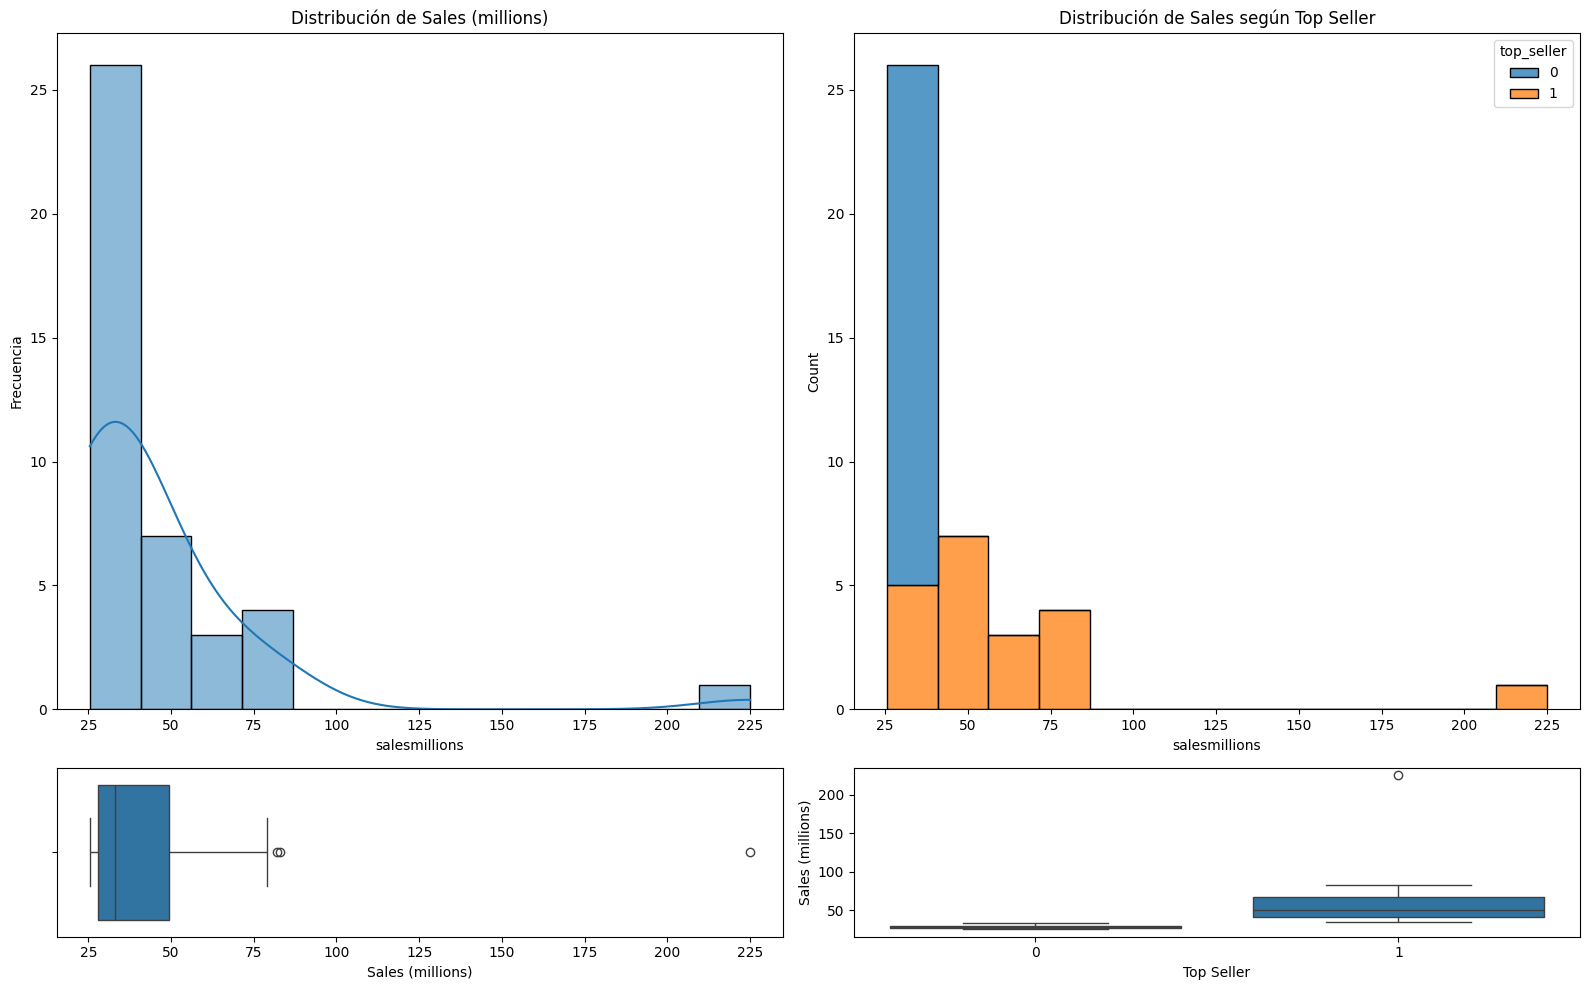

In [13]:
fig, axis = plt.subplots(
    2, 2,
    figsize=(16, 10),
    gridspec_kw={'height_ratios': [4, 1]}
)

sns.histplot(data=df, x="salesmillions", ax=axis[0, 0], kde=True)
sns.boxplot(data=df, x="salesmillions", ax=axis[1, 0])

axis[0, 0].set_title("Distribución de Sales (millions)")
axis[1, 0].set_xlabel("Sales (millions)")
axis[0, 0].set_ylabel("Frecuencia")

sns.histplot(
    data=df,
    x="salesmillions",
    hue="top_seller",
    ax=axis[0, 1],
    multiple="stack"
)

sns.boxplot(data=df, x="top_seller", y="salesmillions", ax=axis[1, 1])

axis[0, 1].set_title("Distribución de Sales según Top Seller")
axis[1, 1].set_xlabel("Top Seller")
axis[1, 1].set_ylabel("Sales (millions)")

plt.tight_layout()
plt.show()

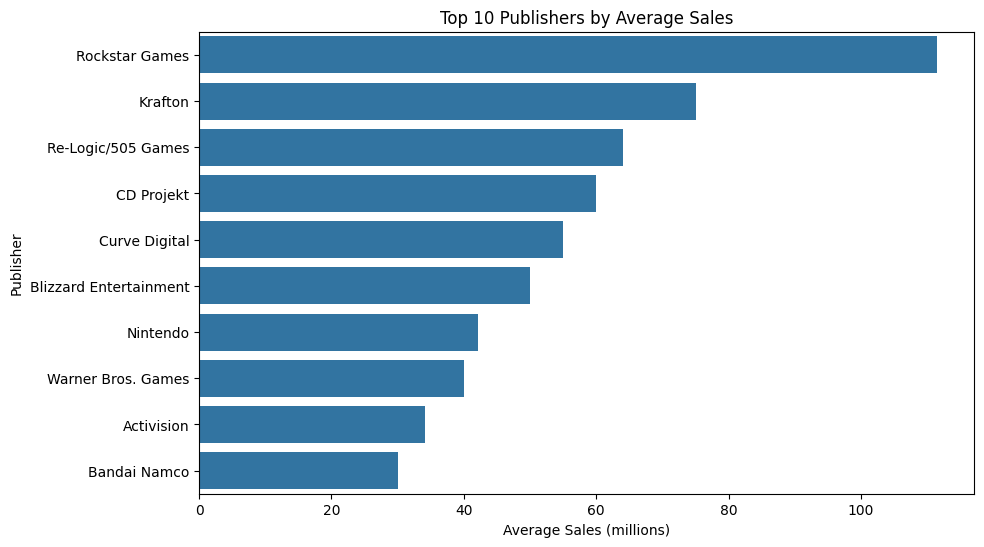

In [14]:
top_publishers = (
    df.groupby("publishers")["salesmillions"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Top 10 Publishers by Average Sales")
plt.xlabel("Average Sales (millions)")
plt.ylabel("Publisher")

plt.show()

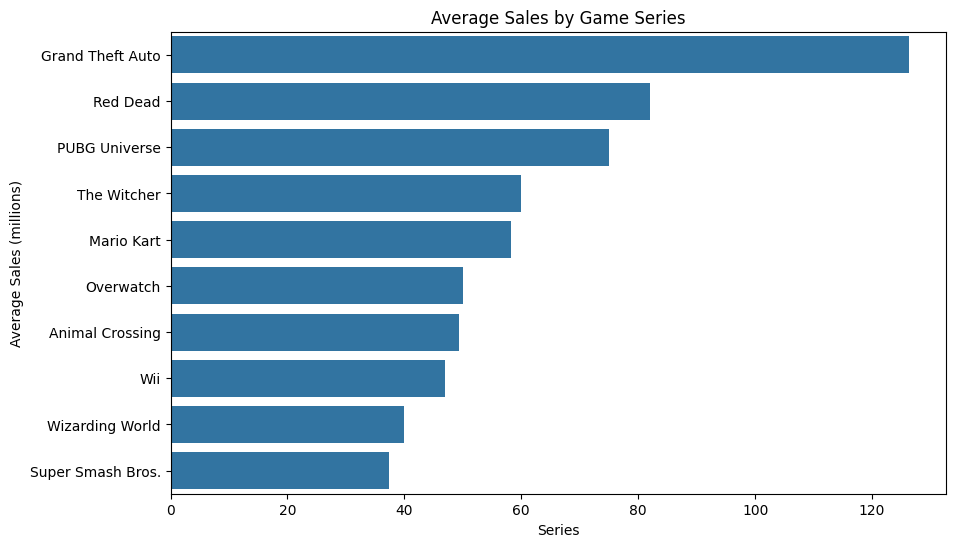

In [15]:
top_publishers = (
    df.groupby("series")["salesmillions"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index
)

plt.title("Average Sales by Game Series")
plt.xlabel("Series")
plt.ylabel("Average Sales (millions)")

plt.show()

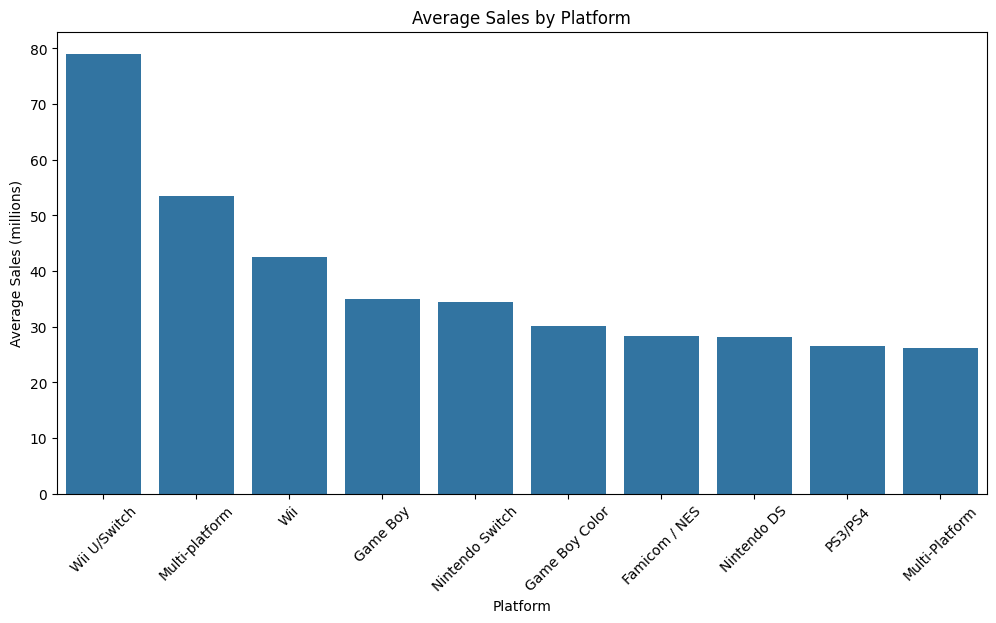

In [16]:
plt.figure(figsize=(12,6))

top_platforms = (
    df.groupby("platforms")["salesmillions"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=top_platforms.index,
    y=top_platforms.values
)

plt.title("Average Sales by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Sales (millions)")

plt.xticks(rotation=45)

plt.show()

## Feature Engineering

In [17]:
df = df.copy()

total_data_CON_outliers = df.copy()
total_data_SIN_outliers = df.copy()

Crear X e y

Seleccionamos las columnas que vamos a usar

In [18]:
predictoras = ["platforms", "publishers", "releaseyear"]
target = "top_seller"

X_CON = df[predictoras]
X_SIN = df[predictoras]


X = df[predictoras]
y = df[target]

Train/Test split

In [19]:
X_train_CON, X_test_CON, y_train, y_test = train_test_split(
    X_CON,
    y,
    test_size=0.2,
    random_state=42
)

X_train_SIN, X_test_SIN = train_test_split(
    X_SIN,
    test_size=0.2,
    random_state=42
)

Preprocesamiento

In [20]:
categorical_features = ["platforms", "publishers"]
numeric_features = ["releaseyear"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)


Crear el modelo Pipeline

In [21]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

Entrenar

In [22]:
model.fit(X_train_CON, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

Evaluar

In [23]:
from sklearn.metrics import accuracy_score

preds = model.predict(X_test_CON)

In [24]:
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.5555555555555556


La performance predictiva de los modelos es limitada porque el dataset carece de variables predictivas fuertes.

# Render

Guardamos el modelo

In [25]:
import pickle 

filename="model.pkl"
pickle.dump(model,open(filename, "wb"))